[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Saving customer_support_tickets.csv to customer_support_tickets.csv


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


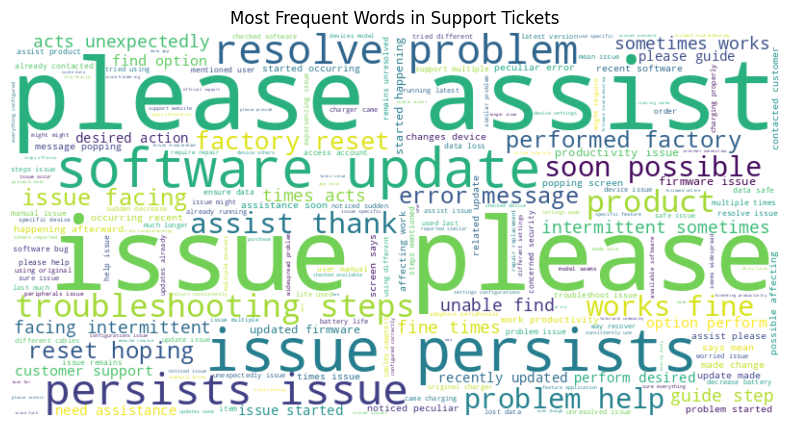

Average First Response Time (Hours): 21232.943359882007
Average Resolution Time (Hours): -0.05770434573251475

Ticket Type Distribution:
Ticket Type
Refund request          20.687212
Technical issue         20.628173
Cancellation request    20.014169
Product inquiry         19.376550
Billing inquiry         19.293895
Name: proportion, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from wordcloud import WordCloud
import nltk
nltk.download('punkt')
nltk.download('stopwords')

# Load data
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("customer_support_tickets.csv")

# Data Cleaning
# Handle missing values
df.fillna({'Resolution': 'Unresolved', 'Customer Satisfaction Rating': 0}, inplace=True)

# Convert dates to datetime
df['First Response Time'] = pd.to_datetime(df['First Response Time'], format='%d-%m-%Y %H:%M')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], format='%d-%m-%Y %H:%M')

# Calculate response times in hours
df['First Response Hours'] = (df['First Response Time'] - pd.to_datetime(df['Date of Purchase'], format='%d-%m-%Y')).dt.total_seconds() / 3600
df['Resolution Hours'] = (df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600

import nltk
nltk.download('punkt_tab') # Download the punkt_tab data package

# Text Analysis for Common Issues
stop_words = set(stopwords.words('english'))
ticket_text = " ".join(df['Ticket Description'].dropna().astype(str))
words = word_tokenize(ticket_text.lower())
filtered_words = [word for word in words if word.isalpha() and word not in stop_words]
common_words = FreqDist(filtered_words).most_common(20)

# Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(filtered_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Support Tickets")
plt.show()

# Summary Statistics
print("Average First Response Time (Hours):", df['First Response Hours'].mean())
print("Average Resolution Time (Hours):", df['Resolution Hours'].mean())
print("\nTicket Type Distribution:")
print(df['Ticket Type'].value_counts(normalize=True) * 100)

# Export Cleaned Data for Tableau
df.to_csv('cleaned_support_tickets.csv', index=False)
files.download('cleaned_support_tickets.csv')

# **Missing values and Datatypes**

In [ ]:
# Import libraries
import pandas as pd
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Read the CSV file
df = pd.read_csv(file_name)

# Dataset Information

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n" + "="*60)
print("COLUMN NAMES")
print("="*60)
print(df.columns.tolist())

# Data Types

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

# Missing Values

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

# Missing Value Percentage

print("\n" + "="*60)
print("MISSING VALUE PERCENTAGE")
print("="*60)

missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.round(2))
# Summary Table

summary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Missing Percentage (%)": ((df.isnull().sum() / len(df)) * 100).round(2).values
})

print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(summary)

# Optional: Save the summary as CSV
summary.to_csv("Data_Summary_Report.csv", index=False)

print("\nData Summary Report saved successfully!")

Saving customer_support_tickets.csv to customer_support_tickets (6).csv
DATASET SHAPE
(8469, 17)

COLUMN NAMES
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

DATA TYPES
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                  

# **Ticket Type Distribution**

Ticket Type Distribution
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


/tmp/ipykernel_16918/4229386725.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ticket Type', palette='Set2')


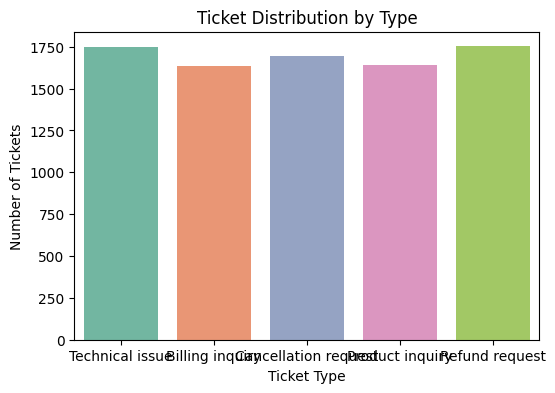

Ticket Priority Distribution
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


/tmp/ipykernel_16918/4229386725.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ticket Priority',


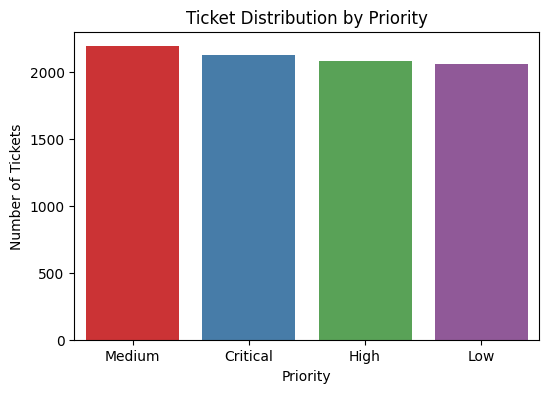

Ticket Category Distribution
Ticket Subject
Refund request           576
Software bug             574
Product compatibility    567
Delivery problem         561
Hardware issue           547
Battery life             542
Network problem          539
Installation support     530
Product setup            529
Payment issue            526
Name: count, dtype: int64


/tmp/ipykernel_16918/4229386725.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


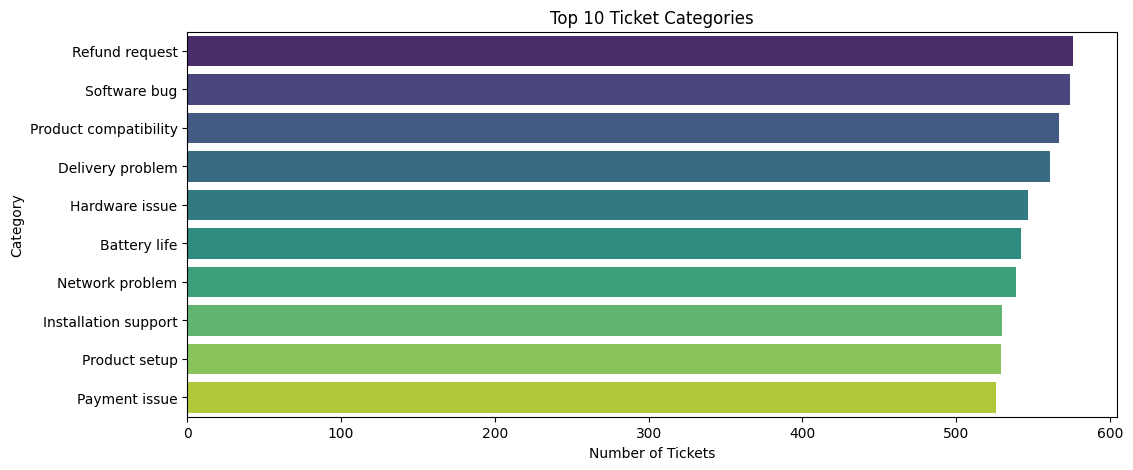

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ticket Type Distribution
print("="*50)
print("Ticket Type Distribution")
print("="*50)

type_distribution = df['Ticket Type'].value_counts()

print(type_distribution)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Ticket Type', palette='Set2')
plt.title("Ticket Distribution by Type")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")
plt.show()

# Ticket Priority Distribution
print("="*50)
print("Ticket Priority Distribution")
print("="*50)

priority_distribution = df['Ticket Priority'].value_counts()

print(priority_distribution)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Ticket Priority',
              order=df['Ticket Priority'].value_counts().index,
              palette='Set1')

plt.title("Ticket Distribution by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.show()

# Ticket Category Distribution
print("="*50)
print("Ticket Category Distribution")
print("="*50)

category_distribution = df['Ticket Subject'].value_counts()

print(category_distribution.head(10))

plt.figure(figsize=(12,5))
sns.countplot(data=df,
              y='Ticket Subject',
              order=df['Ticket Subject'].value_counts().head(10).index,
              palette='viridis')

plt.title("Top 10 Ticket Categories")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")
plt.show()

# Creating new **features**

In [ ]:
import pandas as pd
from google.colab import files

# Upload the dataset
uploaded = files.upload()

# Read the uploaded CSV file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Convert date columns to datetime
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], format='%d-%m-%Y')
df['First Response Time'] = pd.to_datetime(df['First Response Time'], format='%d-%m-%Y %H:%M')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], format='%d-%m-%Y %H:%M')

# Create Resolution_Duration (in hours)
df['Resolution_Duration'] = (
    df['Time to Resolution'] - df['Date of Purchase']
).dt.total_seconds() / 3600

# Create Priority_Score
priority_score = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Critical': 4
}

df['Priority_Score'] = df['Ticket Priority'].map(priority_score)

# Display the new columns
print("New Features Created Successfully!\n")

print(df[['Ticket Priority',
          'Priority_Score',
          'Resolution_Duration']].head())

# Display dataset information
print("\nDataset Shape:", df.shape)
print("\nColumns after Feature Engineering:")
print(df.columns)

Saving customer_support_tickets.csv to customer_support_tickets (8).csv
New Features Created Successfully!

  Ticket Priority  Priority_Score  Resolution_Duration
0        Critical               4                  NaN
1        Critical               4                  NaN
2             Low               1         25266.083333
3             Low               1         22321.950000
4             Low               1         29131.883333

Dataset Shape: (8469, 19)

Columns after Feature Engineering:
Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'Resolution_Duration',
       'Priority_Score'],
      dtype='object')


# **Exploratory Visualization**

customer_support_tickets.csv not found. Please upload the file.


Saving cleaned_support_tickets (1).csv to cleaned_support_tickets (1) (1).csv


/tmp/ipykernel_709/1980127975.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


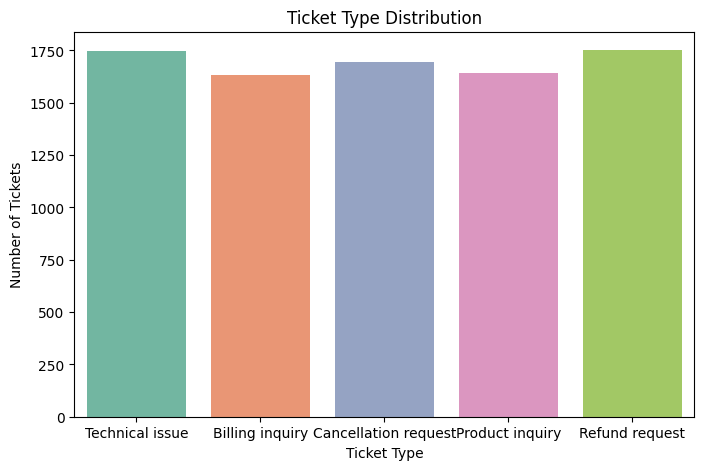

/tmp/ipykernel_709/1980127975.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


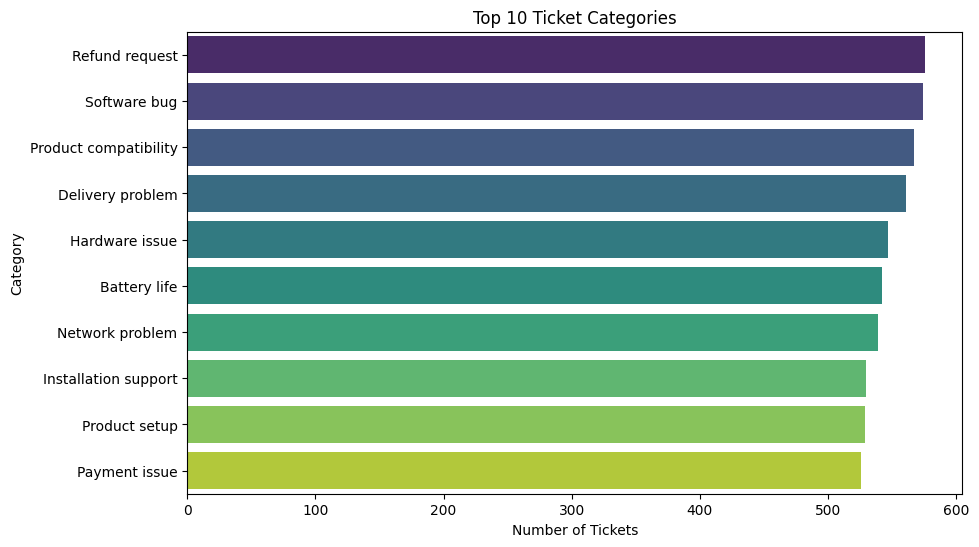

/tmp/ipykernel_709/1980127975.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


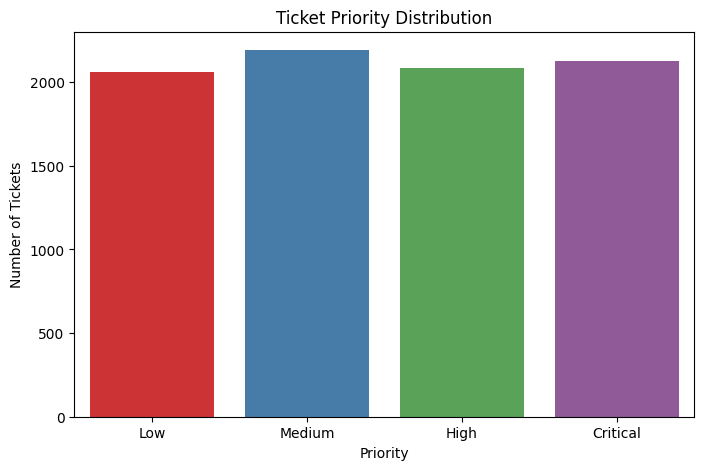

/tmp/ipykernel_709/1980127975.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


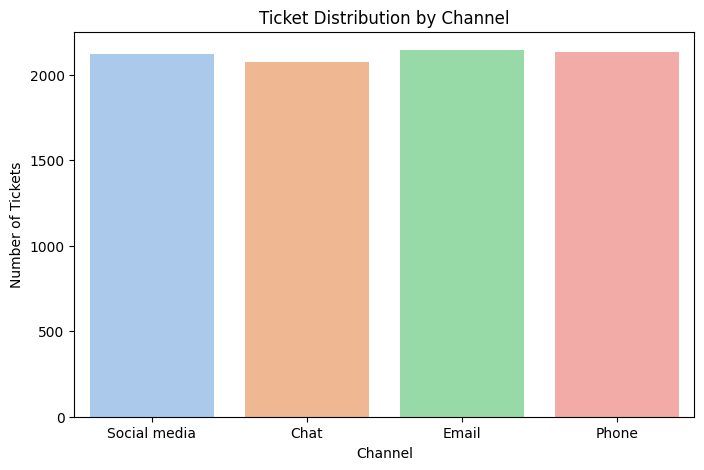

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

try:
    df = pd.read_csv("customer_support_tickets.csv")
except FileNotFoundError:
    print("customer_support_tickets.csv not found. Please upload the file.")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(file_name)


df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], format='%d-%m-%Y')
df['First Response Time'] = pd.to_datetime(df['First Response Time'], format='%d-%m-%Y %H:%M')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], format='%d-%m-%Y %H:%M')

df['Resolution_Duration'] = (
    df['Time to Resolution'] - df['Date of Purchase']
).dt.total_seconds() / 3600

priority_score = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Critical': 4
}
df['Priority_Score'] = df['Ticket Priority'].map(priority_score)

# Ticket Type Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Ticket Type',
    palette='Set2'
)

plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")

plt.show()
# Top 10 Ticket Categories

top_categories = df['Ticket Subject'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index,
    palette='viridis'
)

plt.title("Top 10 Ticket Categories")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")

plt.show()
# Ticket Priority Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Ticket Priority',
    order=['Low','Medium','High','Critical'],
    palette='Set1'
)

plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

plt.show()
# Ticket Channel Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Ticket Channel',
    palette='pastel'
)

plt.title("Ticket Distribution by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Tickets")

plt.show()

# Similarity and Cluster Insights

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
# Prepare Data

cluster_df = df[['Ticket Priority',
                 'Ticket Type',
                 'Customer Satisfaction Rating',
                 'Customer Age']].copy()

cluster_df['Customer Satisfaction Rating'] = cluster_df[
    'Customer Satisfaction Rating'
].fillna(0)

encoder = LabelEncoder()

cluster_df['Ticket Priority'] = encoder.fit_transform(cluster_df['Ticket Priority'])
cluster_df['Ticket Type'] = encoder.fit_transform(cluster_df['Ticket Type'])

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)
# K-Means

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster_ID'] = kmeans.fit_predict(scaled_data)

cluster_names = {
    0:'Priority Support',
    1:'General Queries',
    2:'Technical Issues',
    3:'Critical Incidents'
}

df['Cluster_Name'] = df['Cluster_ID'].map(cluster_names)

# Similarity Score

distances = pairwise_distances(
    scaled_data,
    kmeans.cluster_centers_
)

df['Similarity_Score'] = (
    1/(1+distances.min(axis=1))
).round(2)

# Similarity Level

def similarity(score):

    if score>=0.75:
        return "High"

    elif score>=0.50:
        return "Medium"

    else:
        return "Low"

df['Similarity_Level']=df['Similarity_Score'].apply(similarity)
# Average Similarity Score

print(df.groupby('Cluster_Name')['Similarity_Score'].mean())

# Cluster Size

print(df['Cluster_Name'].value_counts())

Cluster_Name
Critical Incidents    0.376931
General Queries       0.459866
Priority Support      0.447692
Technical Issues      0.441798
Name: Similarity_Score, dtype: float64
Cluster_Name
Technical Issues      2469
Priority Support      2392
General Queries       1943
Critical Incidents    1665
Name: count, dtype: int64


/tmp/ipykernel_709/2782489999.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


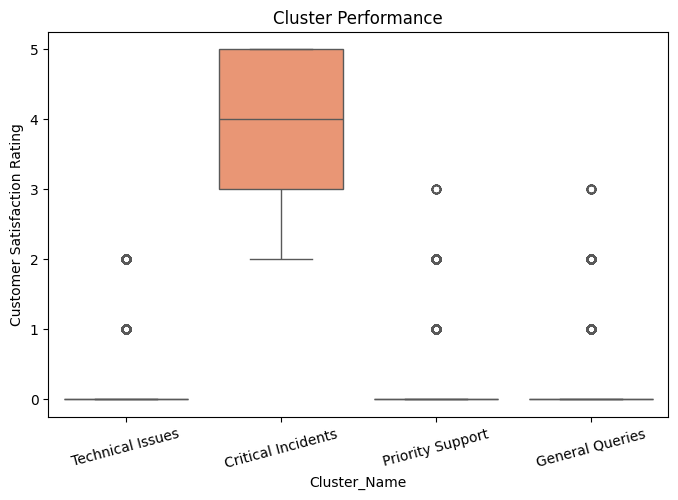

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Cluster_Name',
    y='Customer Satisfaction Rating',
    palette='Set2'
)

plt.title("Cluster Performance")
plt.xticks(rotation=15)

plt.show()

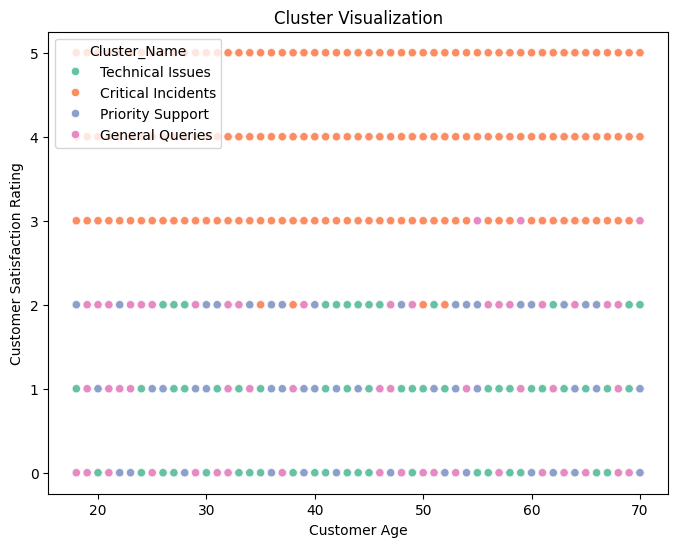

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Customer Age',
    y='Customer Satisfaction Rating',
    hue='Cluster_Name',
    palette='Set2'
)

plt.title("Cluster Visualization")

plt.show()

# **Average Resolution Time by Priority**

/tmp/ipykernel_3389/1003817644.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


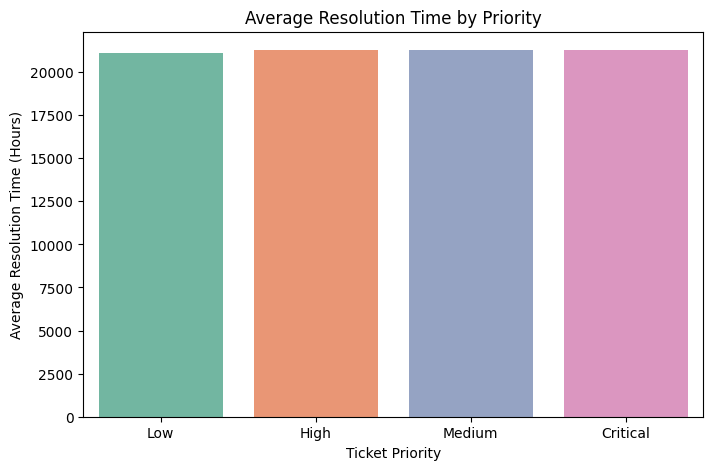


Average Resolution Time by Priority
Ticket Priority
Low         21117.138690
High        21257.173097
Medium      21272.915922
Critical    21279.307415
Name: Resolution_Duration, dtype: float64


/tmp/ipykernel_3389/1003817644.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


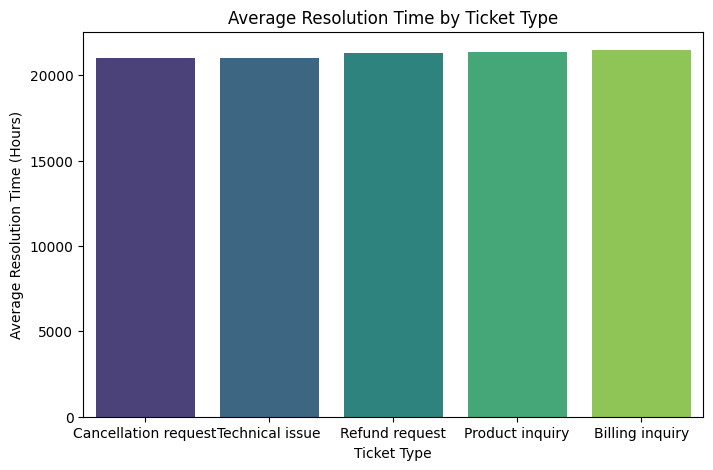


Average Resolution Time by Ticket Type
Ticket Type
Cancellation request    21002.604102
Technical issue         21004.897816
Refund request          21297.792002
Product inquiry         21387.229362
Billing inquiry         21479.528401
Name: Resolution_Duration, dtype: float64

Country column not found in dataset.

Team column not found in dataset.


/tmp/ipykernel_3389/1003817644.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


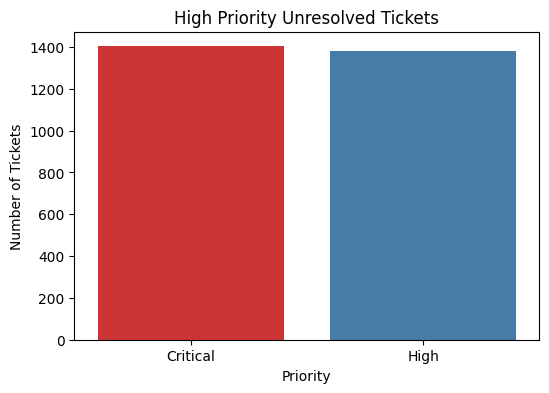


High Priority Unresolved Tickets
    Ticket ID Ticket Priority              Ticket Status
0           1        Critical  Pending Customer Response
1           2        Critical  Pending Customer Response
6           7        Critical                       Open
7           8        Critical                       Open
9          10        Critical  Pending Customer Response
15         16            High  Pending Customer Response
17         18            High  Pending Customer Response
18         19            High                       Open
20         21            High  Pending Customer Response
21         22        Critical  Pending Customer Response


PERFORMANCE METRICS SUMMARY
Total Tickets : 8469
Average Resolution Time : 21234.35 Hours
Resolved Tickets : 2769
Open Tickets : 5700


In [4]:
# ============================================
# Module 5 : Performance Trend Analysis
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# Convert Date Columns
# --------------------------------------------

df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'])

# --------------------------------------------
# Create Resolution Duration
# --------------------------------------------

df['Resolution_Duration'] = (
    df['Time to Resolution'] -
    df['Date of Purchase']
).dt.total_seconds() / 3600

# ============================================
# 1. Average Resolution Time by Priority
# ============================================

priority_avg = (
    df.groupby('Ticket Priority')['Resolution_Duration']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=priority_avg.index,
    y=priority_avg.values,
    palette='Set2'
)

plt.title("Average Resolution Time by Priority")
plt.xlabel("Ticket Priority")
plt.ylabel("Average Resolution Time (Hours)")
plt.show()

print("\nAverage Resolution Time by Priority")
print(priority_avg)

# ============================================
# 2. Average Resolution Time by Ticket Type
# ============================================

ticket_avg = (
    df.groupby('Ticket Type')['Resolution_Duration']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=ticket_avg.index,
    y=ticket_avg.values,
    palette='viridis'
)

plt.title("Average Resolution Time by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Average Resolution Time (Hours)")
plt.show()

print("\nAverage Resolution Time by Ticket Type")
print(ticket_avg)

# ============================================
# 3. Fastest Countries
# ============================================

if 'Country' in df.columns:

    country_avg = (
        df.groupby('Country')['Resolution_Duration']
        .mean()
        .sort_values()
    )

    plt.figure(figsize=(10,6))

    sns.barplot(
        x=country_avg.values,
        y=country_avg.index,
        palette='crest'
    )

    plt.title("Average Resolution Time by Country")
    plt.xlabel("Resolution Time (Hours)")
    plt.ylabel("Country")

    plt.show()

    print("\nTop Fastest Countries")
    print(country_avg)

else:
    print("\nCountry column not found in dataset.")

# ============================================
# 4. Fastest Teams
# ============================================

if 'Team' in df.columns:

    team_avg = (
        df.groupby('Team')['Resolution_Duration']
        .mean()
        .sort_values()
    )

    plt.figure(figsize=(10,6))

    sns.barplot(
        x=team_avg.values,
        y=team_avg.index,
        palette='coolwarm'
    )

    plt.title("Average Resolution Time by Team")
    plt.xlabel("Resolution Time (Hours)")
    plt.ylabel("Support Team")

    plt.show()

    print("\nTop Performing Teams")
    print(team_avg)

else:
    print("\nTeam column not found in dataset.")

# ============================================
# 5. High Priority Unresolved Tickets
# ============================================

high_priority = df[
    (df['Ticket Priority'].isin(['High','Critical'])) &
    (df['Ticket Status'] != 'Closed')
]

plt.figure(figsize=(6,4))

sns.countplot(
    data=high_priority,
    x='Ticket Priority',
    palette='Set1'
)

plt.title("High Priority Unresolved Tickets")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

plt.show()

print("\nHigh Priority Unresolved Tickets")

print(
    high_priority[
        ['Ticket ID',
         'Ticket Priority',
         'Ticket Status']
    ].head(10)
)

# ============================================
# Performance Summary
# ============================================

print("\n")
print("="*60)
print("PERFORMANCE METRICS SUMMARY")
print("="*60)

print("Total Tickets :", len(df))

print("Average Resolution Time :",
      round(df['Resolution_Duration'].mean(),2),
      "Hours")

print("Resolved Tickets :",
      df[df['Ticket Status']=="Closed"].shape[0])

print("Open Tickets :",
      df[df['Ticket Status']!="Closed"].shape[0])

print("="*60)

# **Geographic and Category-Level Insights**

In [5]:
# ============================================
# Module 6 : Geographic & Category-Level Insights
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. Ticket Concentration by Country
# ============================================

if 'Country' in df.columns:

    country_count = df['Country'].value_counts()

    plt.figure(figsize=(10,6))

    sns.barplot(
        x=country_count.values,
        y=country_count.index,
        palette='viridis'
    )

    plt.title("Ticket Concentration by Country")
    plt.xlabel("Number of Tickets")
    plt.ylabel("Country")

    plt.show()

else:
    print("Country column not found.")

# ============================================
# 2. Heatmap of Ticket Distribution
# ============================================

if 'Country' in df.columns and 'Ticket Priority' in df.columns:

    heatmap_data = pd.crosstab(
        df['Country'],
        df['Ticket Priority']
    )

    plt.figure(figsize=(10,7))

    sns.heatmap(
        heatmap_data,
        annot=True,
        cmap='YlGnBu',
        fmt='d'
    )

    plt.title("Ticket Concentration Heatmap")
    plt.xlabel("Ticket Priority")
    plt.ylabel("Country")

    plt.show()

else:
    print("Required columns not available for Heatmap.")

# ============================================
# 3. Issue Categories by Country
# ============================================

if 'Country' in df.columns:

    category_data = pd.crosstab(
        df['Country'],
        df['Ticket Type']
    )

    category_data.plot(
        kind='bar',
        stacked=True,
        figsize=(12,6)
    )

    plt.title("Issue Categories by Country")
    plt.xlabel("Country")
    plt.ylabel("Number of Tickets")

    plt.legend(title="Ticket Type")

    plt.show()

else:
    print("Country column not found.")

# ============================================
# 4. Cluster Size vs Performance Score
# ============================================

if 'Cluster_Name' in df.columns:

    cluster_summary = (
        df.groupby('Cluster_Name')
        .agg({
            'Ticket ID':'count',
            'Customer Satisfaction Rating':'mean'
        })
        .reset_index()
    )

    cluster_summary.columns = [
        'Cluster_Name',
        'Cluster_Size',
        'Performance_Score'
    ]

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=cluster_summary,
        x='Cluster_Size',
        y='Performance_Score',
        hue='Cluster_Name',
        s=250
    )

    plt.title("Cluster Size vs Performance Score")
    plt.xlabel("Cluster Size")
    plt.ylabel("Average Customer Satisfaction")

    plt.show()

else:
    print("Cluster_Name column not found.")

# ============================================
# 5. Customer Satisfaction by Cluster
# ============================================

if 'Cluster_Name' in df.columns:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x='Cluster_Name',
        y='Customer Satisfaction Rating',
        palette='Set2'
    )

    plt.title("Customer Satisfaction by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Customer Satisfaction")

    plt.xticks(rotation=15)

    plt.show()

# ============================================
# 6. Performance Metrics Summary
# ============================================

print("\n")
print("="*60)
print("GEOGRAPHIC & CATEGORY PERFORMANCE SUMMARY")
print("="*60)

if 'Country' in df.columns:
    print("\nTop 10 Countries by Ticket Volume")
    print(df['Country'].value_counts().head(10))

if 'Cluster_Name' in df.columns:
    print("\nCluster Performance Summary")
    print(cluster_summary)

print("\nAverage Customer Satisfaction")
print(round(df['Customer Satisfaction Rating'].mean(),2))

print("\nTotal Tickets")
print(len(df))

print("="*60)

Country column not found.
Required columns not available for Heatmap.
Country column not found.
Cluster_Name column not found.


GEOGRAPHIC & CATEGORY PERFORMANCE SUMMARY

Average Customer Satisfaction
0.98

Total Tickets
8469
